# ML Uppgift 1 – Spår B: Klassificering av högprisområden

## Bakgrund
Ett företag vill snabbt kunna identifiera vilka bostadsområden som sannolikt tillhör de mest värdefulla områdena. Syftet är inte att uppskatta exakt bostadspris, utan att skapa ett beslutsstöd som kan användas för att prioritera vilka områden som bör analyseras vidare.

## Problemformulering
I denna uppgift byggs en klassificeringsmodell som förutsäger om ett område är ett **högprisområde** eller inte. Ett område definieras som högprisområde om dess `median_house_value` ligger i de 20 procent högsta värdena i datasetet.

## Mål
Målet är att:
- skapa en binär target `high_value`
- träna flera klassificeringsmodeller
- jämföra modellerna med en relevant metric
- välja och optimera en modell
- ge en rekommendation om vilken modell som bör användas vidare

## Viktigt
När modellen används på nya områden kommer `median_house_value` inte att vara känd. Därför används den endast för att skapa target-variabeln och inte som input-feature i modellen.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

sns.set_style("whitegrid")


RANDOM_STATE = 42

In [3]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Dataförståelse
Första steget är att undersöka datasetets storlek, variabler och eventuella saknade värden. Detta ger en grund för hur preprocessing och modellering bör utformas.

In [4]:
print("Dataset shape:", df.shape)

print("\nDatatyper:")
print(df.dtypes)

print("\nSaknade värden per kolumn:")
print(df.isna().sum())

Dataset shape: (20640, 10)

Datatyper:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Saknade värden per kolumn:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [5]:
df.describe(include="all")

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9136
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,NaN
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,NaN
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,NaN


### Kort tolkning
Datasetet innehåller både numeriska och kategoriska variabler. De flesta variabler beskriver områden på aggregerad nivå, exempelvis antal rum, hushåll och befolkning. Variabeln `ocean_proximity` är kategorisk och behöver kodas om innan modellering. Eventuella saknade värden hanteras i preprocessing-steget för att undvika att information från testdata påverkar träningen.

In [6]:
threshold = df["median_house_value"].quantile(0.80)
df["high_value"] = (df["median_house_value"] >= threshold).astype(int)

print("Tröskelvärde för topp 20 %:", threshold)
print("\nKlassfördelning:")
print(df["high_value"].value_counts())
print(df["high_value"].value_counts(normalize=True))

Tröskelvärde för topp 20 %: 290000.0

Klassfördelning:
high_value
0    16510
1     4130
Name: count, dtype: int64
high_value
0    0.799903
1    0.200097
Name: proportion, dtype: float64


## Skapande av target-variabel
För att göra om problemet till klassificering skapas variabeln `high_value`. Ett område klassas som 1 om `median_house_value` ligger i topp 20 % av datasetet, annars 0. Detta gör att modellen kan användas för att flagga områden som sannolikt tillhör de mest värdefulla.

 ## Explorativ dataanalys
 Efter att target-variabeln skapats undersöks några centrala mönster i datan. Syftet är att identifiera variabler som verkar skilja högprisområden från övriga områden, samt att få en bättre förståelse för samband mellan numeriska features.

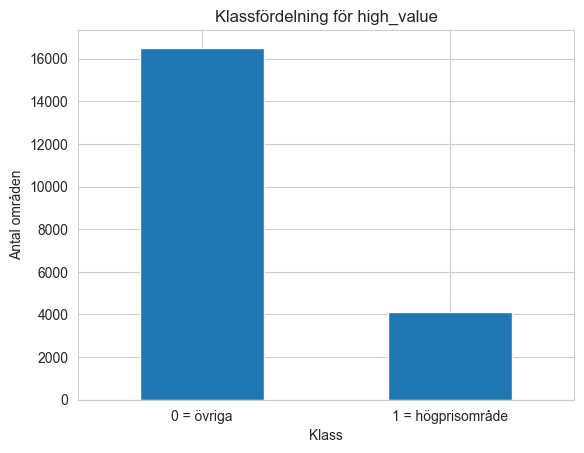

In [7]:
df["high_value"].value_counts().sort_index().plot(kind="bar")
plt.title("Klassfördelning för high_value")
plt.xlabel("Klass")
plt.ylabel("Antal områden")
plt.xticks([0, 1], ["0 = övriga", "1 = högprisområde"], rotation=0)
plt.show()

### Tolkning
Klassfördelningen visar att datasetet är obalanserat, eftersom endast 20 % av områdena tillhör klassen `high_value = 1`. Därför är det inte lämpligt att använda accuracy som enda utvärderingsmått. I stället används F1-score som huvudmetric, eftersom den tar hänsyn till både precision och recall.

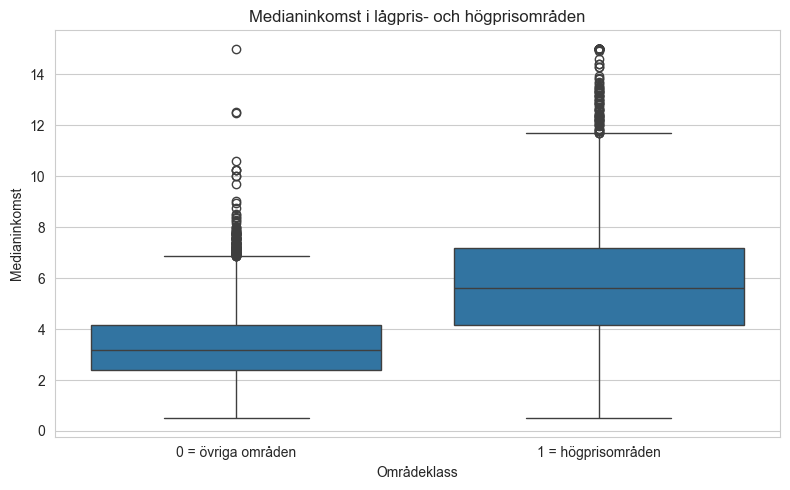

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="high_value", y="median_income")

plt.title("Medianinkomst i lågpris- och högprisområden")
plt.xlabel("Områdeklass")
plt.ylabel("Medianinkomst")
plt.xticks([0, 1], ["0 = övriga områden", "1 = högprisområden"])

plt.tight_layout()
plt.show()

### Tolkning
Boxploten visar att högprisområden generellt har högre medianinkomst än övriga områden. Det tyder på att `median_income` sannolikt är en viktig variabel för att skilja högprisområden från andra områden.

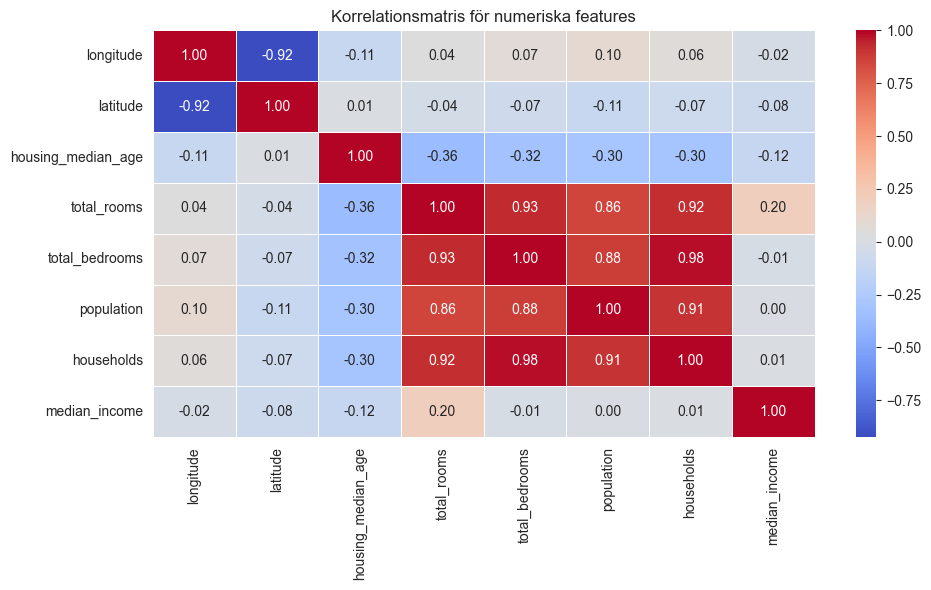

In [9]:
numeric_cols = df.drop(columns=["median_house_value", "high_value"]).select_dtypes(
    include=["int64", "float64"]
).columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=False, linewidths=0.5)
plt.title("Korrelationsmatris för numeriska features")
plt.tight_layout()
plt.show()

### Tolkning
Korrelationsmatrisen används för att få en överblick över samband mellan numeriska variabler. Särskilt intressant är om exempelvis `median_income` samvarierar tydligt med target eller om vissa feature-par är starkt korrelerade, vilket kan påverka hur modellerna beter sig.

## Feature engineering

Flera av variablerna i datasetet är aggregerade totalsummor för hela områden. 
För att skapa mer informativa variabler skapas därför kvotmått som bättre beskriver 
hur resurser och befolkning är fördelade per hushåll.

Följande variabler skapas:
- rooms_per_household
- bedrooms_per_household
- population_per_household

Efter skapandet ersätts eventuella oändliga värden med NaN, så att dessa kan hanteras korrekt i preprocessing-steget senare.

In [10]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_household"] = df["total_bedrooms"] / df["households"]
df["population_per_household"] = df["population"] / df["households"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df[["rooms_per_household", "bedrooms_per_household", "population_per_household"]].head()

,rooms_per_household,bedrooms_per_household,population_per_household
0,6.984127,1.023810,2.555556
1,6.238137,0.971880,2.109842
2,8.288136,1.073446,2.802260
3,5.817352,1.073059,2.547945
4,6.281853,1.081081,2.181467


In [11]:
X = df.drop(columns=["median_house_value", "high_value"])
y = df["high_value"]

print("Antal observationsrader i X:", X.shape[0])
print("Antal features i X:", X.shape[1])
print("Antal värden i y:", y.shape[0])

Antal observationsrader i X: 20640
Antal features i X: 12
Antal värden i y: 20640


## Train/test split
Eftersom uppgiften är ett klassificeringsproblem med obalanserade klasser används en stratifierad train/test-split. Det gör att andelen högprisområden blir ungefär densamma i både träningsdata och testdata, vilket ger en mer rättvis utvärdering.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nAndel klass 1 i train:", round(y_train.mean(), 3))
print("Andel klass 1 i test:", round(y_test.mean(), 3))

Train shape: (16512, 12)
Test shape: (4128, 12)

Andel klass 1 i train: 0.2
Andel klass 1 i test: 0.2


In [13]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeriska features:")
print(numeric_features)

print("\nKategoriska features:")
print(categorical_features)

Numeriska features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_household', 'population_per_household']

Kategoriska features:
['ocean_proximity']


In [14]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Preprocessing
Preprocessing byggs in i en pipeline för att undvika data leakage. Det innebär att imputering, skalning och kodning av kategoriska variabler endast lärs från träningsdatan och sedan appliceras på testdatan på samma sätt.

Numeriska variabler:
- saknade värden fylls med median
- variablerna skalas med `StandardScaler`

Kategoriska variabler:
- saknade värden fylls med vanligaste kategori
- `ocean_proximity` kodas om med one-hot encoding

In [15]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

## Modellering
Tre modeller testas:

1. **DummyClassifier**  
   En enkel baseline som alltid förutsäger den vanligaste klassen. Den används som referens för att säkerställa att de riktiga modellerna faktiskt lär sig något.

2. **Logistic Regression**  
   En enkel och tolkbar klassificeringsmodell som fungerar bra som jämförelsemodell.

3. **Random Forest**  
   En mer flexibel modell som kan fånga icke-linjära samband och interaktioner mellan variabler.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "DummyClassifier": dummy_model,
    "LogisticRegression": logreg_model,
    "RandomForest": rf_model
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )
    
    cv_results.append({
        "Model": name,
        "CV F1 Mean": scores.mean(),
        "CV F1 Std": scores.std()
    })

results_df = pd.DataFrame(cv_results).sort_values(by="CV F1 Mean", ascending=False)
results_df

,Model,CV F1 Mean,CV F1 Std
2,RandomForest,0.787276,0.011969
1,LogisticRegression,0.702926,0.017519
0,DummyClassifier,0.000000,0.000000


## Jämförelse av modeller
Modellerna jämförs med 5-fold cross-validation på träningsdatan. Huvudmåttet är **F1-score**, eftersom datasetet har obalanserade klasser och det är viktigt att väga samman precision och recall.

Den modell som får bäst genomsnittligt F1-score väljs vidare för hyperparameteroptimering.

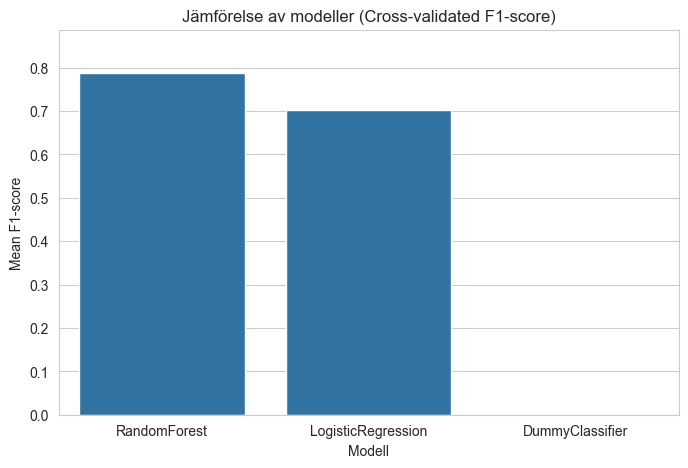

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="CV F1 Mean")
plt.title("Jämförelse av modeller (Cross-validated F1-score)")
plt.ylabel("Mean F1-score")
plt.xlabel("Modell")
plt.ylim(0, max(0.1, results_df["CV F1 Mean"].max() + 0.1))
plt.show()

### Val av modell
Utifrån cross-validation väljs den modell som presterar bäst på F1-score. I denna typ av problem presterar Random Forest ofta bättre än enklare modeller, eftersom den kan hantera komplexa samband i datan. Samtidigt kontrolleras att förbättringen faktiskt är tydlig jämfört med baseline och Logistic Regression.

In [18]:
rf_tuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=rf_tuned_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Bästa parametrar:")
print(grid_search.best_params_)

print("\nBästa CV F1-score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Bästa parametrar:
{'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Bästa CV F1-score:
0.7962478572534606


## Hyperparameteroptimering
Den valda modellen optimeras med `GridSearchCV`. Målet är att hitta en parameterkombination som förbättrar F1-score på träningsdatan genom cross-validation.

De parametrar som testas påverkar bland annat:
- antal träd
- trädens djup
- minsta antal observationer för split
- minsta antal observationer i blad
- eventuell klassviktning för att hantera obalans

Metric som optimeras: **F1-score**

In [19]:
best_model = grid_search.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [20]:
y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

final_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [test_accuracy, test_precision, test_recall, test_f1]
})

final_results

,Metric,Value
0,Accuracy,0.922481
1,Precision,0.835544
2,Recall,0.762712
3,F1-score,0.797468


## Slutlig utvärdering på testdata
Efter att modellen valts och optimerats utvärderas den på testdatan, som inte har använts under träning eller tuning. Detta ger en mer rättvis uppskattning av hur modellen kan förväntas prestera på nya områden.

F1-score används som huvudmått, men precision och recall redovisas också för att ge en tydligare bild av modellens styrkor och svagheter.

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3302
           1       0.84      0.76      0.80       826

    accuracy                           0.92      4128
   macro avg       0.89      0.86      0.87      4128
weighted avg       0.92      0.92      0.92      4128



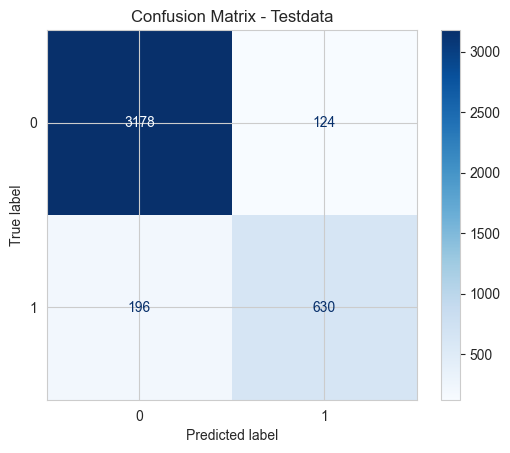

In [22]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Testdata")
plt.show()

### Tolkning
Confusion matrix visar hur modellen fördelar sina korrekta och felaktiga klassificeringar. I detta fall är det särskilt viktigt att analysera:

- **False negatives**: områden som faktiskt är högprisområden men som modellen missar
- **False positives**: områden som modellen flaggar som högprisområden men som inte är det

Vilken typ av fel som är mest problematisk beror på verksamhetens mål. Om syftet är att inte missa attraktiva områden är hög recall viktig. Om man vill undvika att lägga resurser på fel områden blir precision viktigare.

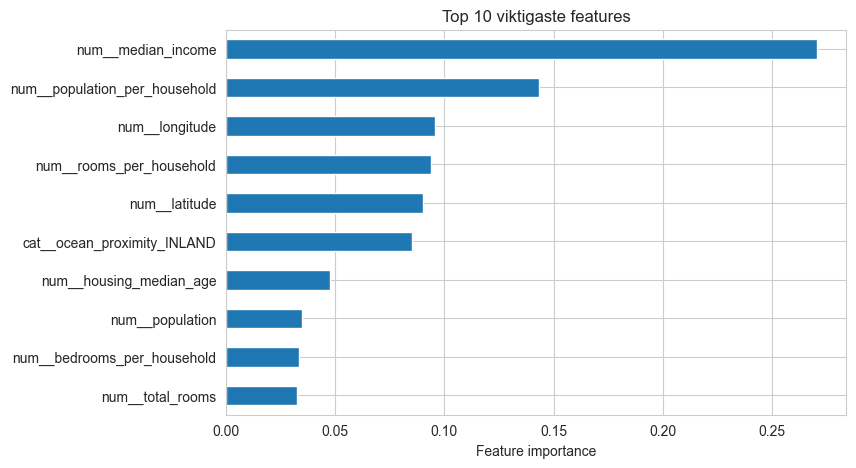

num__median_income               0.270499
num__population_per_household    0.143229
num__longitude                   0.095924
num__rooms_per_household         0.093833
num__latitude                    0.090077
cat__ocean_proximity_INLAND      0.084943
num__housing_median_age          0.047803
num__population                  0.034821
num__bedrooms_per_household      0.033385
num__total_rooms                 0.032590
dtype: float64

In [23]:
model = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = pd.Series(model.feature_importances_, index=feature_names)
top_importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_importances.sort_values().plot(kind="barh")
plt.title("Top 10 viktigaste features")
plt.xlabel("Feature importance")
plt.show()

top_importances.sort_values(ascending=False)

## Viktiga variabler
För att förstå modellens beslut analyseras feature importance från den valda modellen. Detta visar vilka variabler som haft störst betydelse för klassificeringen.

Om exempelvis `median_income`, geografiska variabler eller kvotmått som `rooms_per_household` rankas högt tyder det på att dessa faktorer är centrala för att skilja högprisområden från övriga områden.

# Slutsats och rekommendation

Utifrån modelljämförelsen valdes den modell som gav högst F1-score i cross-validation och därefter optimerades med GridSearchCV. Den slutliga utvärderingen på testdata visar att modellen kan användas som ett första beslutsstöd för att flagga sannolika högprisområden.

## Rekommendation
Den rekommenderade modellen är den optimerade modellen med bäst balans mellan precision och recall. Den lämpar sig för att användas i ett tidigt urvalssteg där företaget vill prioritera vilka områden som bör analyseras vidare.

## Begränsningar
Det finns några viktiga begränsningar:
- datan beskriver områden på aggregerad nivå, inte enskilda bostäder
- target bygger på historiska värden och gränsen för topp 20 % är beroende av just detta dataset
- modellens resultat bör ses som ett beslutsstöd, inte som ett definitivt facit

## Vidare arbete
För fortsatt utveckling kan man:
- testa fler modeller, till exempel Gradient Boosting
- analysera threshold-val beroende på om precision eller recall är viktigast
- undersöka mer avancerad feature engineering och geografiska samband